In [8]:
from pathlib import Path
import json
import calendar
from datetime import datetime, timedelta
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import geodatasets

# Collecting data

## Earthquake event catalog


Best method to collect data is to use their API to get chunks of data in `GeoJSON` format before converting them to one large dataframe and store it as a parquet file 

ANSS Comprehensive Earthquake Catalog (ComCat) Documentation: [https://earthquake.usgs.gov/data/comcat](https://earthquake.usgs.gov/data/comcat)
  
API documentation: [https://earthquake.usgs.gov/fdsnws/event/1/](https://earthquake.usgs.gov/fdsnws/event/1/)

In [9]:
BASE_URL = "https://earthquake.usgs.gov/fdsnws/event/1/query"


def fetch_comcat_chunk(
    starttime: str,
    endtime: str,
    minmagnitude: float = 2.5,
    offset: int = 1,
    limit: int = 20000,
    eventtype: str = "earthquake",
    orderby: str = "time-asc",
):
    """
    Fetch one ComCat chunk from the API and return the GeoJSON response as dict.
    starttime/endtime should be strings like '2018-01-01' or ISO datetime strings.
    """
    params = {
        "format": "geojson",
        "eventtype": eventtype,
        "starttime": starttime,
        "endtime": endtime,
        "minmagnitude": minmagnitude,
        "orderby": orderby,
        "limit": limit,
        "offset": offset,
    }

    r = requests.get(BASE_URL, params=params, timeout=60)
    r.raise_for_status()
    return r.json()


def save_raw_geojson(data: dict, filepath: Path):
    """
    Save a GeoJSON dict to disk.
    """
    filepath.parent.mkdir(parents=True, exist_ok=True)
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(data, f)


def month_ranges(start_date: str, end_date: str):
    """
    Yield monthly date ranges covering [start_date, end_date].

    Returns tuples:
        (chunk_start_str, chunk_end_str, year, month)

    Example:
        ('2018-01-01', '2018-01-31', 2018, 1)
    """
    start = datetime.strptime(start_date, "%Y-%m-%d").date()
    end = datetime.strptime(end_date, "%Y-%m-%d").date()

    if start > end:
        raise ValueError("start_date must be <= end_date")

    current = start.replace(day=1)

    while current <= end:
        year = current.year
        month = current.month
        last_day = calendar.monthrange(year, month)[1]

        chunk_start = max(start, current)
        chunk_end = min(end, current.replace(day=last_day))

        yield (
            chunk_start.isoformat(),
            chunk_end.isoformat(),
            year,
            month,
        )

        if month == 12:
            current = current.replace(year=year + 1, month=1, day=1)
        else:
            current = current.replace(month=month + 1, day=1)


def download_comcat_range(
    start_date: str,
    end_date: str,
    output_dir: str = "data/raw/comcat",
    minmagnitude: float = 2.5,
    refresh: bool = False,
    verbose: bool = True,
):
    """
    Download ComCat data month by month over a user-specified date range.

    - If a month's GeoJSON file already exists, skip it unless refresh=True.
    - Saves one GeoJSON file per month.

    Returns:
        list[Path] of all expected filepaths
    """
    output_dir = Path(output_dir)
    saved_files = []

    for chunk_start, chunk_end, year, month in month_ranges(start_date, end_date):
        year_dir = output_dir / str(year)
        filename = f"comcat_{year}_{month:02d}.geojson"
        filepath = year_dir / filename

        saved_files.append(filepath)

        if filepath.exists() and not refresh:
            if verbose:
                print(f"[SKIP] Already exists: {filepath}")
            continue

        if verbose:
            print(f"[FETCH] {chunk_start} to {chunk_end} -> {filepath}")

        data = fetch_comcat_chunk(
            starttime=chunk_start,
            endtime=chunk_end,
            minmagnitude=minmagnitude,
        )
        save_raw_geojson(data, filepath)

        if verbose:
            n = len(data.get("features", []))
            print(f"[DONE] Saved {n} events to {filepath}")

    return saved_files

    

In [10]:
# downloading all the comcat data in geojson format
file_paths = download_comcat_range(
    start_date="2015-01-01",
    end_date="2025-12-31",
    output_dir="data/raw/comcat",
    minmagnitude=2.5,
    refresh=False,
    verbose=False
)

# ComCat GeoJSON — concise descriptive metadata

This file is a **GeoJSON FeatureCollection** of earthquake events returned by the USGS/ANSS ComCat query.

## Top-level structure

### `type`
- Usually `"FeatureCollection"`
- Indicates that the file contains a collection of geospatial features

### `metadata`
- Information about the query result itself, not about individual earthquakes
- Common uses:
  - dataset title
  - API status / response code
  - generated timestamp
  - result count
  - API URL used for the query

### `features`
- A list of earthquake event records
- **Each item in `features` = one earthquake event**

### `bbox`
- Bounding box for all returned events
- Usually in the form:
  - `[min_longitude, min_latitude, min_depth, max_longitude, max_latitude, max_depth]`
- Describes the overall spatial extent of the returned data

---

## Structure of each event in `features`

Each event contains 4 main parts:

### `type`
- Usually `"Feature"`
- Standard GeoJSON label for one feature/object

### `id`
- Unique ComCat event identifier
- Best used as the event’s primary key

### `geometry`
- Spatial location of the event

#### `geometry.type`
- Usually `"Point"`
- Means the earthquake is represented as a single location point

#### `geometry.coordinates`
- A 3-value list:
  - `[longitude, latitude, depth]`
- Meaning:
  - index `0`: longitude
  - index `1`: latitude
  - index `2`: depth in km

### `properties`
- Non-spatial metadata about the earthquake
- This is where most of the useful tabular fields are stored

---

## `properties` fields in your sample

### Event size / seismic measurement

#### `mag`
- Earthquake magnitude
- Numeric event strength value

#### `magType`
- Magnitude type
- Examples may include:
  - `ml`
  - `mb`
  - `mw`
  - `mwr`
- Important because magnitudes from different scales are not exactly the same

---

### Event timing

#### `time`
- Event origin time
- Stored as Unix timestamp in **milliseconds**
- This is the main event occurrence time

#### `updated`
- Last update time for the event record
- Also in Unix timestamp milliseconds
- Useful to know whether the record was revised later

#### `tz`
- Time zone offset field
- Often null or less important for analysis
- Usually you should rely on `time` and convert to UTC datetime

---

### Event location / description

#### `place`
- Human-readable description of location
- Example style:
  - `"74km NW of Kota Ternate, Indonesia"`

#### `title`
- Human-readable event title
- Usually combines magnitude and place
- Example style:
  - `"M 4.6 - 74km NW of Kota Ternate, Indonesia"`

---

### Event links / identifiers

#### `url`
- Web page for the event summary

#### `detail`
- API endpoint with more detailed event information
- Useful if you later want richer metadata or products

#### `code`
- Event code within the reporting network

#### `net`
- Reporting seismic network code
- Identifies the source network/provider

#### `ids`
- Comma-separated list of associated event IDs
- May include IDs from different contributing systems

#### `sources`
- Comma-separated list of source networks contributing to the event record

#### `types`
- Comma-separated list of product/data types available for the event
- Can indicate what additional information exists for that event

---

### Event quality / reliability / intensity-related fields

#### `status`
- Review status of the event
- Often useful to distinguish:
  - automatically generated records
  - reviewed records

#### `sig`
- Significance score
- A general event significance measure used by USGS

#### `nst`
- Number of seismic stations used
- Can be useful as a rough quality indicator

#### `dmin`
- Distance to nearest station
- Smaller values may indicate better local constraint

#### `rms`
- Root mean square of travel-time residuals
- Often used as a location-quality indicator

#### `gap`
- Azimuthal gap
- Describes station coverage around the event
- Lower values are often better

---

### Shaking / public impact / hazard fields

#### `felt`
- Number of felt reports submitted by people
- Can be null if unavailable

#### `cdi`
- Community Determined Intensity
- Public-reported shaking intensity estimate

#### `mmi`
- Modified Mercalli Intensity
- Instrumental or estimated shaking intensity

#### `alert`
- Alert level for hazard impact
- Can be null or values like color-coded alert categories

#### `tsunami`
- Tsunami flag
- Usually indicates whether the event was flagged for tsunami consideration

---

### Event classification

#### `type`
- Event type
- Often `"earthquake"`
- Useful in case other event types appear in a broader query

---

## What matters most for your project

For your aftershock prediction task, the most important fields are:

- `id`
- `time`
- `geometry.coordinates[0]` → longitude
- `geometry.coordinates[1]` → latitude
- `geometry.coordinates[2]` → depth
- `mag`
- `magType`
- `status`
- `gap`
- `dmin`
- `rms`
- `nst`
- `net`
- `type`

---

## Best way to think about this file

- `metadata` = information about the query result
- `features` = all earthquake events returned
- one item in `features` = one earthquake
- `geometry` = where it happened
- `properties` = what happened and supporting metadata

In [11]:
RECOMMENDED_COLUMNS = [
    "event_id",
    "time",
    "updated",
    "latitude",
    "longitude",
    "depth_km",
    "magnitude",
    "magnitude_type",
    "status",
    "event_type",
    "net",
    "gap",
    "dmin",
    "rms",
    "nst",
]


def comcat_geojson_to_dataframe(filepath: str | Path) -> pd.DataFrame:
    """
    Read one ComCat GeoJSON file and convert it into a flat dataframe.

    Parameters
    ----------
    filepath : str | Path
        Path to one ComCat GeoJSON file.

    Returns
    -------
    pd.DataFrame
        Dataframe with one row per earthquake event.
    """
    filepath = Path(filepath)

    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    features = data.get("features", [])
    rows = []

    for feature in features:
        props = feature.get("properties", {})
        geom = feature.get("geometry", {})
        coords = geom.get("coordinates", [None, None, None])

        longitude = coords[0] if len(coords) > 0 else None
        latitude = coords[1] if len(coords) > 1 else None
        depth_km = coords[2] if len(coords) > 2 else None

        row = {
            "event_id": feature.get("id"),
            "time": props.get("time"),
            "updated": props.get("updated"),
            "latitude": latitude,
            "longitude": longitude,
            "depth_km": depth_km,
            "magnitude": props.get("mag"),
            "magnitude_type": props.get("magType"),
            "status": props.get("status"),
            "event_type": props.get("type"),
            "net": props.get("net"),
            "gap": props.get("gap"),
            "dmin": props.get("dmin"),
            "rms": props.get("rms"),
            "nst": props.get("nst"),
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    if df.empty:
        return pd.DataFrame(columns=RECOMMENDED_COLUMNS)

    # convert timestamps from unix milliseconds to datetime
    df["time"] = pd.to_datetime(df["time"], unit="ms", utc=True, errors="coerce")
    df["updated"] = pd.to_datetime(df["updated"], unit="ms", utc=True, errors="coerce")

    # enforce column order
    df = df[RECOMMENDED_COLUMNS]

    # optional: sort within file
    df = df.sort_values("time").reset_index(drop=True)

    return df


def month_start(dt: datetime) -> datetime:
    return dt.replace(day=1)


def next_month(dt: datetime) -> datetime:
    if dt.month == 12:
        return dt.replace(year=dt.year + 1, month=1, day=1)
    return dt.replace(month=dt.month + 1, day=1)


def iter_months(start_date: str, end_date: str):
    """
    Yield (year, month) pairs from start_date to end_date inclusive.
    Dates must be YYYY-MM-DD.
    """
    start_dt = datetime.strptime(start_date, "%Y-%m-%d")
    end_dt = datetime.strptime(end_date, "%Y-%m-%d")

    if start_dt > end_dt:
        raise ValueError("start_date must be <= end_date")

    current = month_start(start_dt)

    while current <= end_dt:
        yield current.year, current.month
        current = next_month(current)


def build_comcat_filepath(
    root_dir: str | Path,
    year: int,
    month: int,
) -> Path:
    """
    Build filepath like:
    data/raw/comcat/2015/comcat_2015_01.geojson
    """
    root_dir = Path(root_dir)
    return root_dir / str(year) / f"comcat_{year}_{month:02d}.geojson"


def load_comcat_date_range(
    start_date: str,
    end_date: str,
    root_dir: str | Path = "data/raw/comcat",
    skip_missing: bool = True,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Load and combine all ComCat GeoJSON files whose month falls within
    the provided date range.

    Parameters
    ----------
    start_date : str
        YYYY-MM-DD
    end_date : str
        YYYY-MM-DD
    root_dir : str | Path
        Root directory containing yearly ComCat folders.
    skip_missing : bool
        If True, skip missing files. If False, raise FileNotFoundError.
    verbose : bool
        If True, print progress.

    Returns
    -------
    pd.DataFrame
        Combined dataframe filtered to the exact start/end date.
    """
    frames = []

    for year, month in iter_months(start_date, end_date):
        filepath = build_comcat_filepath(root_dir, year, month)

        if not filepath.exists():
            if skip_missing:
                if verbose:
                    print(f"[SKIP] Missing file: {filepath}")
                continue
            raise FileNotFoundError(f"Missing file: {filepath}")

        if verbose:
            print(f"[LOAD] {filepath}")

        df_month = comcat_geojson_to_dataframe(filepath)
        frames.append(df_month)

    if not frames:
        return pd.DataFrame(columns=RECOMMENDED_COLUMNS)

    df = pd.concat(frames, ignore_index=True)

    # filter to exact requested date range
    start_ts = pd.Timestamp(start_date, tz="UTC")
    end_ts = pd.Timestamp(end_date, tz="UTC") + pd.Timedelta(days=1)

    df = df[(df["time"] >= start_ts) & (df["time"] < end_ts)].copy()

    df = df.sort_values("time").reset_index(drop=True)

    return df

def build_and_save_comcat_dataset(
    start_date: str,
    end_date: str,
    root_dir: str | Path = "data/raw/comcat",
    output_path: str | Path = "data/raw/comcat/comcat.parquet",
    skip_missing: bool = True,
    verbose: bool = True,
) -> pd.DataFrame:
    df = load_comcat_date_range(
        start_date=start_date,
        end_date=end_date,
        root_dir=root_dir,
        skip_missing=skip_missing,
        verbose=verbose,
    )

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.suffix == ".csv":
        df.to_csv(output_path, index=False)
    elif output_path.suffix == ".parquet":
        df.to_parquet(output_path, index=False)
    else:
        raise ValueError("output_path must end with .csv or .parquet")


In [12]:
# Save the combined dataframe to Parquet for future use
comcat_df_2015_2024 = build_and_save_comcat_dataset(
    start_date="2015-01-01",
    end_date="2024-12-31",
    root_dir="data/raw/comcat",
    output_path="data/raw/comcat/comcat_2015_2024.parquet",
    verbose=False,
)

# ComCat Dataset Overview

The ANSS Comprehensive Earthquake Catalog (ComCat) is a seismic event catalog that records earthquake occurrences together with their key physical, spatial, temporal, and quality-related attributes.  
For this project, ComCat serves as the **core event-level dataset** because it provides the essential information needed to identify:

- when an earthquake happened
- where it happened
- how large it was
- whether it can be treated as a candidate mainshock or aftershock
- how reliable the event record is

Each row in the cleaned tabular dataset represents **one earthquake event**.  
This allows us to sort events over time, measure distances between earthquakes, identify mainshock–aftershock pairs, and construct the prediction target:

**Given a mainshock of $M \ge 4.0$, predict how many hours until the next $M \ge 2.5$ aftershock occurs within 50 km, capped at 720 hours.**

## Selected Features and Why They Were Chosen

- `event_id`
  - Unique identifier for each earthquake event
  - Useful for deduplication, traceability, and linking records across processing steps

- `time`
  - Timestamp of when the earthquake occurred
  - Essential for ordering events and computing the target variable: time until the next qualifying aftershock

- `updated`
  - Timestamp of when the event record was last revised
  - Useful for understanding whether event information was later corrected or refined

- `latitude`
  - Geographic latitude of the earthquake epicenter
  - Needed to compute spatial distance between events

- `longitude`
  - Geographic longitude of the earthquake epicenter
  - Needed together with latitude to determine whether a later event is within 50 km of the mainshock

- `depth_km`
  - Depth of the earthquake in kilometers
  - May influence aftershock behaviour and provides additional physical context about the event

- `magnitude`
  - Numeric measure of earthquake size
  - Essential for identifying mainshocks ($M \ge 4.0$) and candidate aftershocks ($M \ge 2.5$)

- `magnitude_type`
  - Type of magnitude measurement used (for example, local magnitude or moment magnitude)
  - Helps account for differences in magnitude scales across events

- `status`
  - Indicates whether the event was automatically generated or reviewed
  - Useful as a proxy for record reliability and data quality

- `event_type`
  - Describes the type of seismic event
  - Helps ensure only true earthquake events are used in the analysis

- `net`
  - Reporting seismic network code
  - Useful for traceability and for capturing possible differences across contributing networks

- `gap`
  - Azimuthal gap in station coverage around the event
  - Acts as a quality indicator for how well the event location was constrained

- `dmin`
  - Distance to the nearest seismic station
  - Useful as a data quality signal, since events recorded farther from stations may be less precise

- `rms`
  - Root mean square of travel-time residuals
  - Another quality-related measure indicating how well the event solution fits the observations

- `nst`
  - Number of seismic stations used in the event solution
  - Can serve as a proxy for confidence in the event’s estimated parameters

## Summary

The selected ComCat features were chosen for three main reasons:

- **Target construction**  
  Needed to define mainshocks, aftershocks, time differences, and 50 km spatial constraints

- **Predictive value**  
  Provide physical and temporal information that may influence aftershock timing

- **Data quality control**  
  Help identify whether an event record is reliable enough to be used for modelling

# Exploratory Data Analysis

## Import data and clean data

In [13]:
comcat_df_raw = pd.read_parquet("data/raw/comcat/comcat_2015_2024.parquet").copy()

COMCAT_CLEAN_PATH = Path("data/interim/comcat/comcat_clean_events.parquet")
FORCE_RECOMPUTE = False

if COMCAT_CLEAN_PATH.exists() and not FORCE_RECOMPUTE:
    comcat_df_clean = pd.read_parquet(COMCAT_CLEAN_PATH)
    print(f"Loaded existing cleaned data from {COMCAT_CLEAN_PATH}")
else:
    comcat_df_clean = comcat_df_raw.copy()

    # keep track of row counts
    cleaning_log = []

    def log_step(step_name, df_before, df_after):
        cleaning_log.append({
            "step": step_name,
            "rows_before": len(df_before),
            "rows_after": len(df_after),
            "rows_removed": len(df_before) - len(df_after),
        })

    # 0. standardise categorical text fields
    before = comcat_df_clean.copy()

    if "status" in comcat_df_clean.columns:
        comcat_df_clean["status"] = comcat_df_clean["status"].apply(
            lambda x: x.strip().lower() if isinstance(x, str) else x
        )

    if "event_type" in comcat_df_clean.columns:
        comcat_df_clean["event_type"] = comcat_df_clean["event_type"].apply(
            lambda x: x.strip().lower() if isinstance(x, str) else x
        )

    if "magnitude_type" in comcat_df_clean.columns:
        comcat_df_clean["magnitude_type"] = comcat_df_clean["magnitude_type"].apply(
            lambda x: x.strip().lower() if isinstance(x, str) else x
        )

    log_step("Standardise categorical text fields", before, comcat_df_clean)

    # 1. drop exact duplicate event IDs
    before = comcat_df_clean.copy()
    comcat_df_clean = comcat_df_clean.drop_duplicates(subset="event_id", keep="first")
    log_step("Drop duplicate event_id", before, comcat_df_clean)

    # 2. keep only earthquake events
    before = comcat_df_clean.copy()
    comcat_df_clean = comcat_df_clean.loc[comcat_df_clean["event_type"] == "earthquake"].copy()
    log_step("Keep only event_type == 'earthquake'", before, comcat_df_clean)

    # 3. drop rows missing core fields needed for target construction
    core_cols = ["event_id", "time", "latitude", "longitude", "depth_km", "magnitude"]
    before = comcat_df_clean.copy()
    comcat_df_clean = comcat_df_clean.dropna(subset=core_cols).copy()
    log_step("Drop rows missing core fields", before, comcat_df_clean)

    # 4. valid coordinate ranges
    before = comcat_df_clean.copy()
    comcat_df_clean = comcat_df_clean.loc[
        comcat_df_clean["latitude"].between(-90, 90) &
        comcat_df_clean["longitude"].between(-180, 180)
    ].copy()
    log_step("Keep valid latitude/longitude ranges", before, comcat_df_clean)

    # 5. optional sanity checks on magnitude/depth
    before = comcat_df_clean.copy()
    comcat_df_clean = comcat_df_clean.loc[
        comcat_df_clean["magnitude"] >= 2.5
    ].copy()
    log_step("Keep magnitude >= 2.5", before, comcat_df_clean)

    # depth can be negative in some catalogs due to estimation/reference effects,
    # so do NOT remove negative depths blindly unless you justify it
    # for now, just keep them and inspect later

    # 6. sort by time
    comcat_df_clean = comcat_df_clean.sort_values("time").reset_index(drop=True)

    # 7. Save the cleaned dataframe to Parquet for future use
    COMCAT_CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)
    comcat_df_clean.to_parquet(COMCAT_CLEAN_PATH, index=False)

    cleaning_log_df = pd.DataFrame(cleaning_log)
    cleaning_log_df

Loaded existing cleaned data from data/interim/comcat/comcat_clean_events.parquet


### Cleaning decisions
- Removed duplicate event IDs to avoid double-counting the same earthquake.
- Kept only records with `event_type = earthquake` to ensure consistency with the project objective.
- Dropped rows missing core fields required for target construction, namely time, magnitude, latitude, longitude, and depth.
- Retained negative depth values for now because some seismic catalogs may contain them due to estimation or reference effects; these will be inspected separately rather than removed blindly.
- Kept all event statuses at this stage, while noting that reviewed vs automatic records may later be compared as part of sensitivity analysis.

## A. Dataset overview

This section provides a high-level summary of the cleaned ComCat event dataset used for the project.

The goal is to quickly understand:
- the size of the dataset
- the time coverage
- the available features
- missing values
- duplicates
- whether there are obvious data quality issues before target construction

In [14]:
overview = pd.DataFrame({
    "metric": [
        "Number of rows",
        "Number of columns",
        "Start time",
        "End time",
        "Unique event IDs",
    ],
    "value": [
        comcat_df_clean.shape[0],
        comcat_df_clean.shape[1],
        comcat_df_clean["time"].min(),
        comcat_df_clean["time"].max(),
        comcat_df_clean["event_id"].nunique(),
    ]
})

overview

,metric,value
0,Number of rows,272045
1,Number of columns,15
2,Start time,2015-01-01 00:10:00.590000+00:00
3,End time,2024-12-30 23:56:29.977000+00:00
4,Unique event IDs,272045


In [15]:
comcat_df_clean.head()

,event_id,time,updated,latitude,longitude,depth_km,magnitude,magnitude_type,status,event_type,net,gap,dmin,rms,nst
0,usc000tg4w,2015-01-01 00:10:00.590000+00:00,2015-03-27 07:00:52.040000+00:00,-3.2525,146.1942,10.000,4.4,mb,reviewed,earthquake,us,127.0,1.677,0.52,NaN
1,usc000tb61,2015-01-01 00:26:09.600000+00:00,2024-06-13 23:36:55.123000+00:00,36.6558,-97.6348,5.319,3.0,ml,reviewed,earthquake,us,61.0,NaN,0.64,NaN
2,usc000tg4x,2015-01-01 00:36:10.240000+00:00,2015-03-27 07:00:53.040000+00:00,64.6073,-17.6866,5.710,4.3,mb,reviewed,earthquake,us,121.0,1.571,0.76,NaN
3,usc000tb39,2015-01-01 00:45:11.940000+00:00,2023-07-25 16:32:56.881000+00:00,53.7520,-165.6360,61.800,4.2,mb,reviewed,earthquake,us,NaN,NaN,1.44,NaN
4,usc000tg4y,2015-01-01 00:55:43.100000+00:00,2015-03-27 07:00:53.040000+00:00,81.6983,118.4063,10.000,4.3,mb,reviewed,earthquake,us,75.0,10.371,0.69,NaN


In [16]:
column_summary = pd.DataFrame({
    "column": comcat_df_clean.columns,
    "dtype": comcat_df_clean.dtypes.astype(str).values,
    "non_null_count": comcat_df_clean.notna().sum().values,
    "missing_count": comcat_df_clean.isna().sum().values,
    "missing_pct": (comcat_df_clean.isna().mean() * 100).round(2).values,
})

column_summary

,column,dtype,non_null_count,missing_count,missing_pct
0,event_id,str,272045,0,0.00
1,time,"datetime64[ms, UTC]",272045,0,0.00
2,updated,"datetime64[ms, UTC]",272045,0,0.00
3,latitude,float64,272045,0,0.00
4,longitude,float64,272045,0,0.00
5,depth_km,float64,272045,0,0.00
6,magnitude,float64,272045,0,0.00
7,magnitude_type,str,272044,1,0.00
8,status,str,272045,0,0.00
9,event_type,str,272045,0,0.00


In [17]:
missing_summary = (
    comcat_df_clean.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: (x["missing_count"] / len(comcat_df_clean) * 100).round(2))
    .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_pct
nst,158436,58.24
dmin,40892,15.03
gap,24424,8.98
rms,133,0.05
magnitude_type,1,0.00
event_id,0,0.00
time,0,0.00
updated,0,0.00
latitude,0,0.00
longitude,0,0.00


In [18]:
duplicate_event_ids = comcat_df_clean["event_id"].duplicated().sum()

pd.DataFrame({
    "check": ["Duplicate event_id rows"],
    "value": [duplicate_event_ids]
})

,check,value
0,Duplicate event_id rows,0


In [19]:
comcat_df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,272045.0,18.716347,30.441168,-82.8837,-5.2225,19.4005,42.5548,87.3860
longitude,272045.0,-37.994471,124.398422,-179.9997,-153.6609,-71.3856,111.6142,179.9994
depth_km,272045.0,59.452309,111.240939,-3.7400,10.0000,14.8000,54.0300,686.3900
magnitude,272045.0,3.771223,0.881220,2.5000,2.8800,4.1000,4.5000,8.3000
gap,247621.0,129.996004,74.949694,7.0000,70.0000,114.0000,183.0000,358.0000
dmin,231153.0,2.558682,4.187350,0.0000,0.4040,1.2580,3.0170,127.4200
rms,271912.0,0.595333,0.348526,0.0000,0.3300,0.6000,0.8100,46.2400
nst,113609.0,34.386448,32.914704,0.0000,15.0000,24.0000,42.0000,619.0000


### Key observations

- The cleaned ComCat dataset contains **272,048 earthquake events** across **15 selected features**, covering the period from **2015-01-01** to **2024-12-30**.
- The number of **unique `event_id` values matches the number of rows**, indicating that duplicate event records have been successfully removed.
- Core fields required for target construction — **`time`, `latitude`, `longitude`, `depth_km`, and `magnitude`** — contain **no missing values** after cleaning. This is important because these variables are essential for identifying mainshocks, computing distances, and constructing the aftershock target.
- All retained rows have **`event_type = earthquake`**, so the cleaned dataset is aligned with the project objective and excludes non-earthquake event types.
- The cleaned dataset contains only events with **`magnitude >= 2.5`**, consistent with the chosen ComCat download threshold and suitable for later identifying candidate aftershocks.
- Most records are marked as **`reviewed` / `REVIEWED`**, while only a small minority are `automatic` or `manual`. This suggests that the majority of events are likely to be relatively reliable, though event status may still be useful as a quality-related feature.
- Missingness is concentrated in quality-related variables, especially **`nst`**, **`dmin`**, and **`gap`**, while **`rms`** is nearly complete. These fields may still be useful for modelling, but they may require imputation, filtering, or selective use.
- Earthquake depths span a wide range, including a small number of **negative depth values**. These are retained for now because such values can appear in seismic catalogs due to location estimation or reference effects, but they should be examined further before final modelling.
- Overall, the cleaned dataset appears suitable as the base event table for subsequent target construction and labelled mainshock analysis.

## B. Base event distributions

This section explores the overall distribution of earthquake events in the cleaned ComCat dataset.

The goal is to understand:
- how earthquake magnitudes and depths are distributed
- how event frequency changes over time
- how events are distributed spatially
- whether some categories dominate the dataset

### B1. Magnitude distribution

In [20]:
comcat_df_clean["magnitude"].describe()

count    272045.000000
mean          3.771223
std           0.881220
min           2.500000
25%           2.880000
50%           4.100000
75%           4.500000
max           8.300000
Name: magnitude, dtype: float64

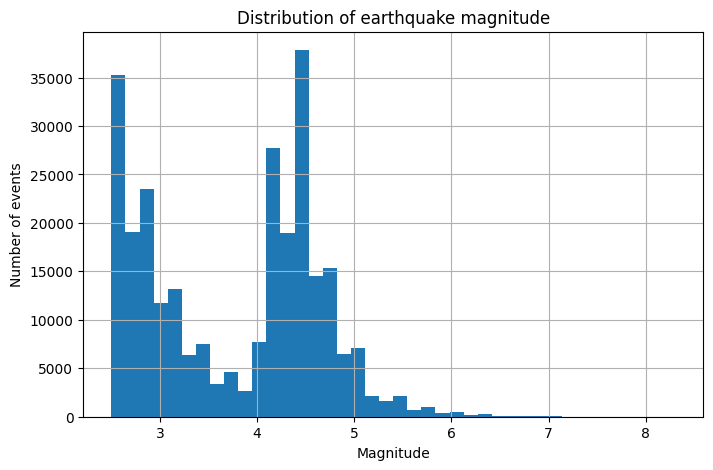

In [21]:
plt.figure(figsize=(8, 5))
comcat_df_clean["magnitude"].hist(bins=40)
plt.xlabel("Magnitude")
plt.ylabel("Number of events")
plt.title("Distribution of earthquake magnitude")
plt.show()

### B2. Depth distribution

In [22]:
comcat_df_clean["depth_km"].describe()

count    272045.000000
mean         59.452309
std         111.240939
min          -3.740000
25%          10.000000
50%          14.800000
75%          54.030000
max         686.390000
Name: depth_km, dtype: float64

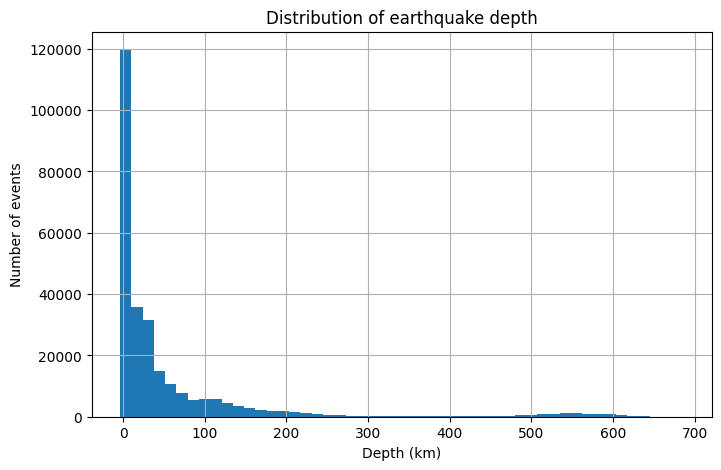

In [23]:
plt.figure(figsize=(8, 5))
comcat_df_clean["depth_km"].hist(bins=50)
plt.xlabel("Depth (km)")
plt.ylabel("Number of events")
plt.title("Distribution of earthquake depth")
plt.show()

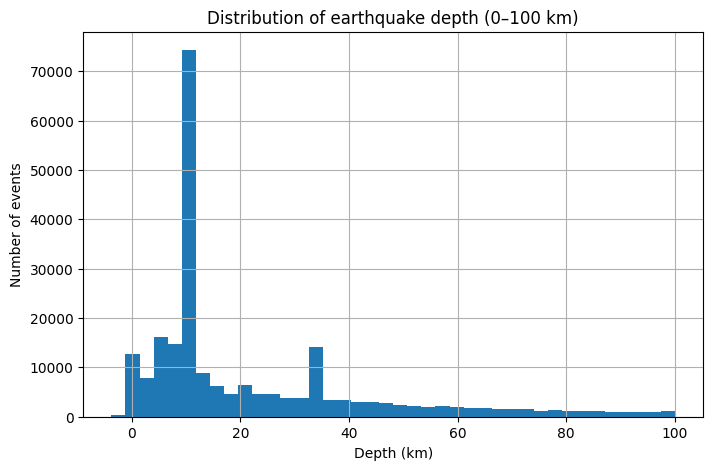

In [24]:
plt.figure(figsize=(8, 5))
comcat_df_clean.loc[comcat_df_clean["depth_km"] <= 100, "depth_km"].hist(bins=40)
plt.xlabel("Depth (km)")
plt.ylabel("Number of events")
plt.title("Distribution of earthquake depth (0–100 km)")
plt.show()

### B3. Event counts over time

In [25]:
events_per_year = (
    comcat_df_clean
    .assign(year=comcat_df_clean["time"].dt.year)
    .groupby("year")
    .size()
    .rename("event_count")
    .reset_index()
)

events_per_year

,year,event_count
0,2015,25939
1,2016,24318
2,2017,21898
3,2018,39410
4,2019,25656
5,2020,31105
6,2021,27690
7,2022,25730
8,2023,26216
9,2024,24083


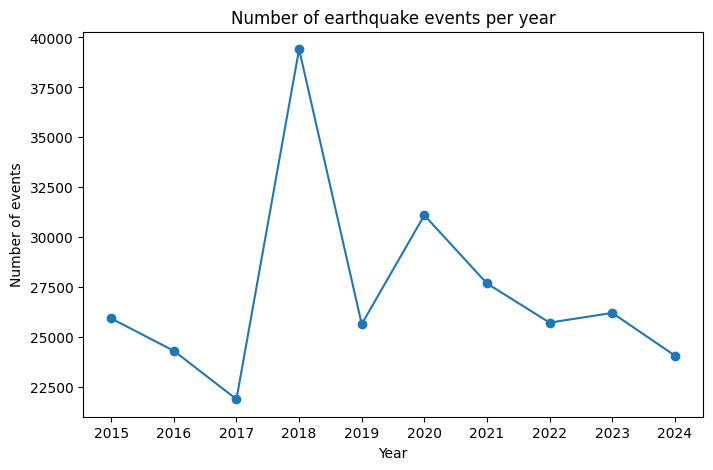

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(events_per_year["year"], events_per_year["event_count"], marker="o")
plt.xlabel("Year")
plt.ylabel("Number of events")
plt.title("Number of earthquake events per year")
plt.xticks(events_per_year["year"])
plt.show()

In [27]:
events_per_month = (
    comcat_df_clean
    .set_index("time")
    .resample("ME")
    .size()
    .rename("event_count")
    .reset_index()
)

events_per_month.head()

,time,event_count
0,2015-01-31 00:00:00+00:00,2070
1,2015-02-28 00:00:00+00:00,1860
2,2015-03-31 00:00:00+00:00,2020
3,2015-04-30 00:00:00+00:00,1926
4,2015-05-31 00:00:00+00:00,2368


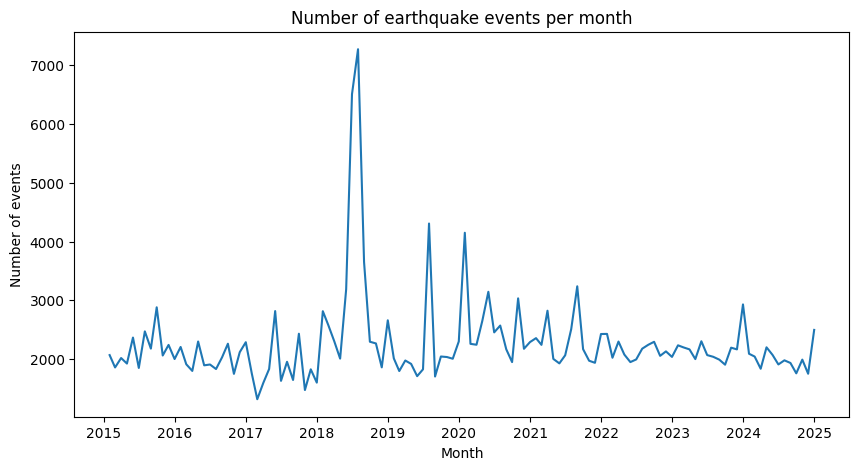

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(events_per_month["time"], events_per_month["event_count"])
plt.xlabel("Month")
plt.ylabel("Number of events")
plt.title("Number of earthquake events per month")
plt.show()

### B4. Spatial distribution of events

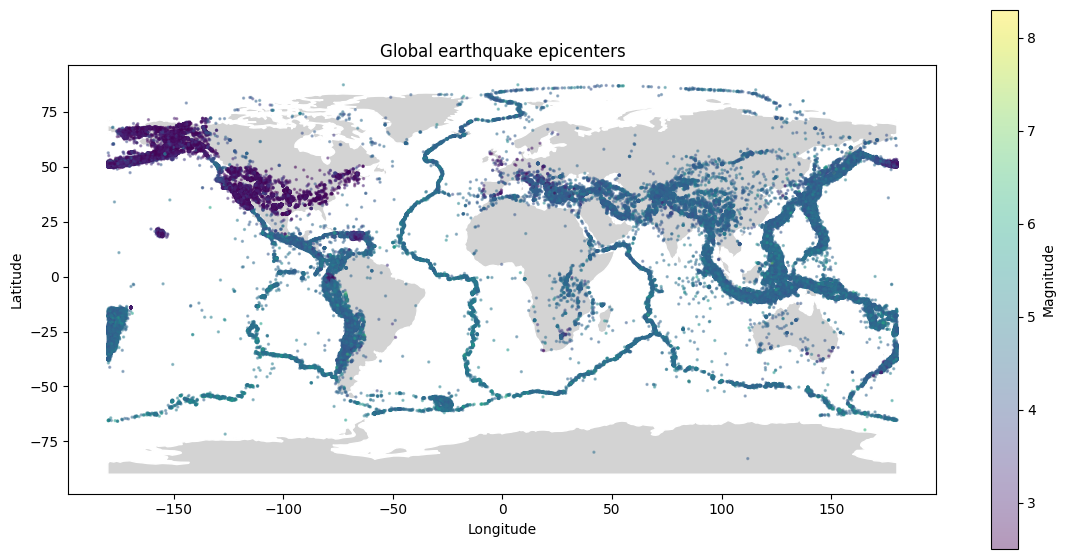

In [29]:
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

fig, ax = plt.subplots(figsize=(14, 7))
world.plot(ax=ax, color="lightgray", edgecolor="white")

scatter = ax.scatter(
    comcat_df_clean["longitude"],
    comcat_df_clean["latitude"],
    c=comcat_df_clean["magnitude"],
    s=2,
    alpha=0.4
)

plt.colorbar(scatter, ax=ax, label="Magnitude")
ax.set_title("Global earthquake epicenters")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()



### Magnitude type distribution

In [30]:
magtype_counts = comcat_df_clean["magnitude_type"].value_counts(dropna=False)
magtype_counts

magnitude_type
mb            131814
ml             90821
md             30349
mww             9889
mwr             5413
mb_lg           1554
mw              1400
mlr              262
mwb              220
ml(texnet)       143
mwc               82
mh                46
mc                20
mlv               11
mlg               10
mwp                9
unknown            1
NaN                1
Name: count, dtype: int64

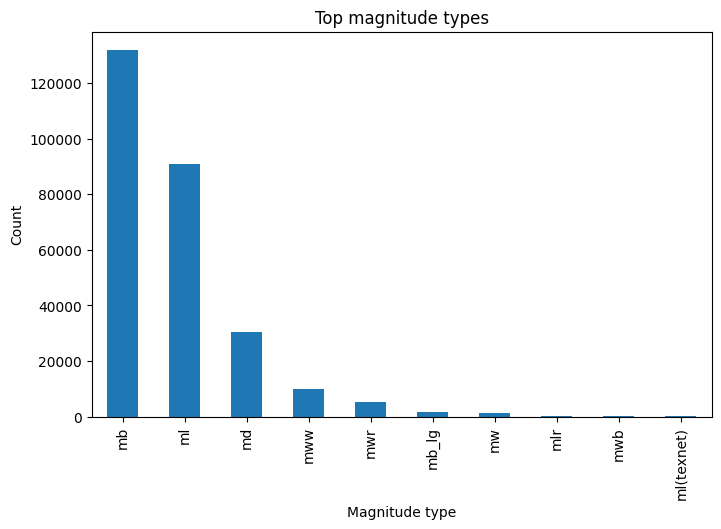

In [31]:
plt.figure(figsize=(8, 5))
magtype_counts.head(10).plot(kind="bar")
plt.xlabel("Magnitude type")
plt.ylabel("Count")
plt.title("Top magnitude types")
plt.show()

### B6. Status distribution

In [32]:
status_counts = comcat_df_clean["status"].value_counts(dropna=False)
status_counts

status
reviewed     269927
automatic      2116
manual            2
Name: count, dtype: int64

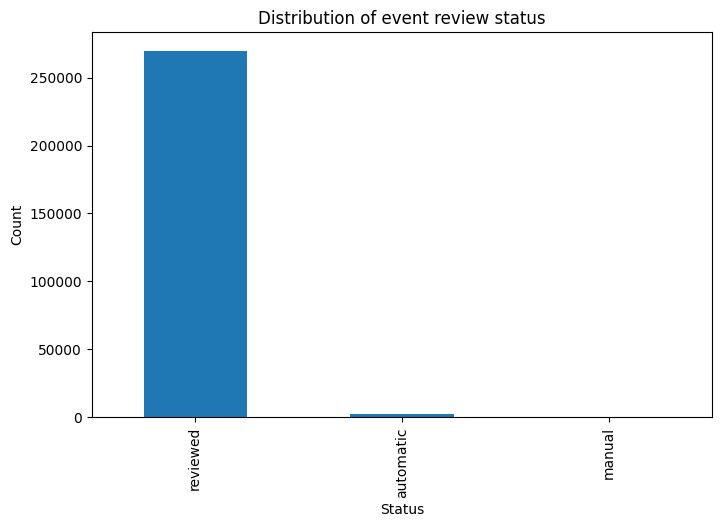

In [33]:
plt.figure(figsize=(8, 5))
status_counts.plot(kind="bar")
plt.xlabel("Status")
plt.ylabel("Count")
plt.title("Distribution of event review status")
plt.show()

### B7. Reporting network distribution

In [34]:
net_counts = comcat_df_clean["net"].value_counts(dropna=False).head(10)
net_counts

net
us       189587
pr        25422
ak        18731
hv        16421
ci         7074
nc         5740
nn         2834
tx         2705
aacse       968
uu          773
Name: count, dtype: int64

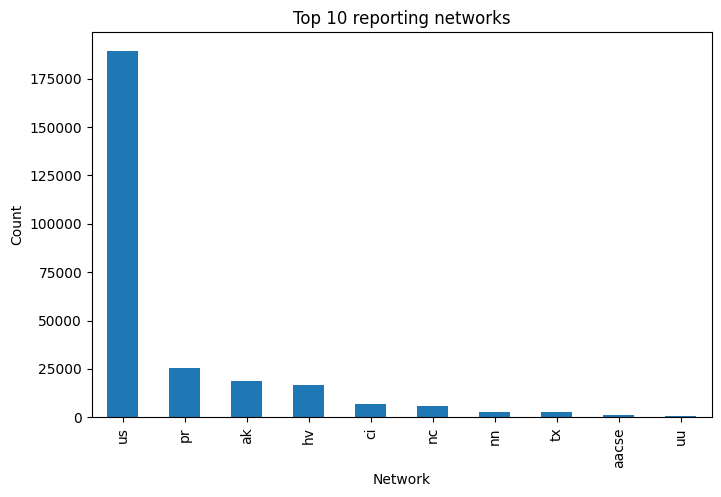

In [35]:
plt.figure(figsize=(8, 5))
net_counts.plot(kind="bar")
plt.xlabel("Network")
plt.ylabel("Count")
plt.title("Top 10 reporting networks")
plt.show()

### B8. Magnitude vs depth

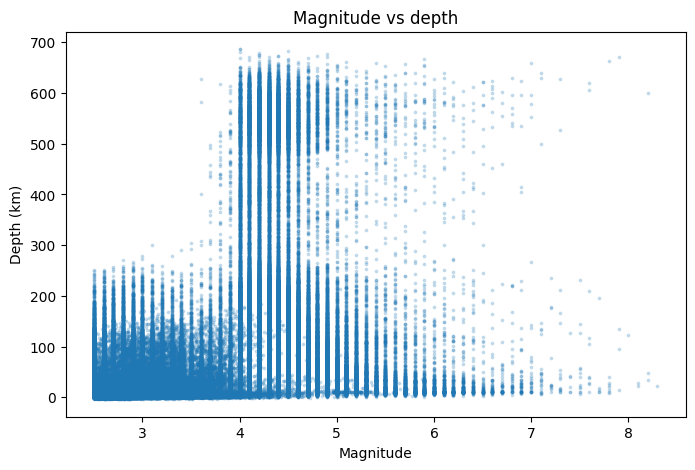

In [36]:
plt.figure(figsize=(8, 5))
plt.scatter(
    comcat_df_clean["magnitude"],
    comcat_df_clean["depth_km"],
    s=3,
    alpha=0.2
)
plt.xlabel("Magnitude")
plt.ylabel("Depth (km)")
plt.title("Magnitude vs depth")
plt.show()

### Key observations

- **Magnitude distribution:** Earthquake magnitudes range from **2.5 to 8.3**, with most events concentrated between **3.0 and 5.0**. The distribution is right-skewed, with far fewer large earthquakes than moderate ones. This is expected in seismic catalogs and is useful for the project because only a subset of these events will qualify as mainshocks (**`M >= 4.0`**).

- **Depth distribution:** Earthquake depths vary widely, but most events are concentrated at relatively shallow depths, especially within the upper **100 km**. This is relevant because shallow earthquakes are often more closely associated with aftershock activity near the epicenter. A small number of negative depth values remain and should be treated cautiously in later modelling.

- **Event counts over time:** Event frequency varies across both years and months, with clear fluctuations rather than a uniform pattern. This suggests temporal clustering in the catalog, which is consistent with earthquake sequence behaviour and supports the importance of time-based analysis for the project.

- **Spatial distribution:** Earthquakes are globally distributed, with strong concentrations in seismically active regions such as the Pacific Ring of Fire, Alaska, and parts of the Mediterranean. This indicates substantial spatial heterogeneity, meaning that regional seismic behaviour may differ and could affect model generalisation.

- **Magnitude type distribution:** Multiple magnitude scales are present, with `mb`, `ml`, and `md` being the most common. This variation is important because different magnitude types may not be directly comparable, so `magnitude_type` should be retained as a feature or at least considered during modelling and interpretation.

- **Status distribution:** The vast majority of events are labelled as reviewed, while only a small proportion are automatic or manual. This supports the overall reliability of the cleaned dataset, although status may still be helpful as a quality-control feature.

- **Reporting network distribution:** A few seismic networks contribute a large proportion of the records, particularly `us`, followed by networks such as `pr`, `ak`, and `hv`. This suggests possible source-network differences in reporting practices, station coverage, or event quality, which may influence downstream analyses.

- **Magnitude vs depth:** There is no strong simple linear relationship between magnitude and depth, although many large events occur at relatively shallow to intermediate depths. This suggests that depth may carry useful but nonlinear information for predicting aftershock timing.

## C. Target construction summary

This section converts the cleaned event-level earthquake catalog into a **mainshock-level supervised dataset**.

For each earthquake event with magnitude $M \ge 4.0$, we:
- treat it as a candidate mainshock
- search forward in time for the next earthquake with magnitude $M \ge 2.5$
- require that the later event occurs within 50 km
- compute the time difference in hours
- cap the target at 720 hours (30 days)

The goal is to understand:
- how many candidate mainshocks exist
- how many have a qualifying aftershock within 720 hours
- how many are capped at 720 hours
- how the target variable is distributed

In [37]:
MAINSHOCK_MIN_MAG = 4.0
AFTERSHOCK_MIN_MAG = 2.5
MAX_RADIUS_KM = 50.0
MAX_HOURS = 720.0

mainshocks_df = (
    comcat_df_clean.loc[comcat_df_clean["magnitude"] >= MAINSHOCK_MIN_MAG]
    .sort_values("time")
    .reset_index(drop=True)
)

pd.DataFrame({
    "metric": [
        "Candidate mainshocks (M >= 4.0)",
        "Total cleaned events",
    ],
    "value": [
        len(mainshocks_df),
        len(comcat_df_clean),
    ]
})

,metric,value
0,Candidate mainshocks (M >= 4.0),144693
1,Total cleaned events,272045


In [38]:
def haversine_km(lat1, lon1, lat2, lon2):
    """
    Great-circle distance between two points on Earth in kilometers.
    """
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [39]:
COMCAT_TARGET_PATH = Path("data/interim/comcat/mainshock_target_dataset.parquet")
FORCE_RECOMPUTE = False


if COMCAT_TARGET_PATH.exists() and not FORCE_RECOMPUTE:
    target_df = pd.read_parquet(COMCAT_TARGET_PATH)
    print(f"Loaded existing target data from {COMCAT_TARGET_PATH}")
else:
    target_rows = []
    events_df = comcat_df_clean.sort_values("time").reset_index(drop=True)

    for _, mainshock in mainshocks_df.iterrows():
        mainshock_time = mainshock["time"]
        mainshock_lat = mainshock["latitude"]
        mainshock_lon = mainshock["longitude"]

        # only look forward in time, within 720 hours
        future_events = events_df.loc[
            (events_df["time"] > mainshock_time) &
            (events_df["time"] <= mainshock_time + pd.Timedelta(hours=MAX_HOURS)) &
            (events_df["magnitude"] >= AFTERSHOCK_MIN_MAG)
        ].copy()

        if future_events.empty:
            target_rows.append({
                "mainshock_event_id": mainshock["event_id"],
                "mainshock_time": mainshock["time"],
                "mainshock_latitude": mainshock["latitude"],
                "mainshock_longitude": mainshock["longitude"],
                "mainshock_depth_km": mainshock["depth_km"],
                "mainshock_magnitude": mainshock["magnitude"],
                "mainshock_magnitude_type": mainshock["magnitude_type"],
                "mainshock_status": mainshock["status"],
                "mainshock_gap": mainshock["gap"],
                "mainshock_dmin": mainshock["dmin"],
                "mainshock_rms": mainshock["rms"],
                "mainshock_nst": mainshock["nst"],
                "next_aftershock_event_id": None,
                "next_aftershock_time": pd.NaT,
                "next_aftershock_magnitude": np.nan,
                "next_aftershock_distance_km": np.nan,
                "target_hours_raw": np.nan,
                "target_hours_capped": MAX_HOURS,
                "has_aftershock_within_720h": False,
                "is_capped_720h": True,
            })
            continue

        future_events["distance_km"] = haversine_km(
            mainshock_lat,
            mainshock_lon,
            future_events["latitude"].values,
            future_events["longitude"].values,
        )

        qualifying = future_events.loc[future_events["distance_km"] <= MAX_RADIUS_KM].copy()

        if qualifying.empty:
            target_rows.append({
                "mainshock_event_id": mainshock["event_id"],
                "mainshock_time": mainshock["time"],
                "mainshock_latitude": mainshock["latitude"],
                "mainshock_longitude": mainshock["longitude"],
                "mainshock_depth_km": mainshock["depth_km"],
                "mainshock_magnitude": mainshock["magnitude"],
                "mainshock_magnitude_type": mainshock["magnitude_type"],
                "mainshock_status": mainshock["status"],
                "mainshock_gap": mainshock["gap"],
                "mainshock_dmin": mainshock["dmin"],
                "mainshock_rms": mainshock["rms"],
                "mainshock_nst": mainshock["nst"],
                "next_aftershock_event_id": None,
                "next_aftershock_time": pd.NaT,
                "next_aftershock_magnitude": np.nan,
                "next_aftershock_distance_km": np.nan,
                "target_hours_raw": np.nan,
                "target_hours_capped": MAX_HOURS,
                "has_aftershock_within_720h": False,
                "is_capped_720h": True,
            })
            continue

        next_aftershock = qualifying.sort_values("time").iloc[0]
        target_hours = (next_aftershock["time"] - mainshock_time).total_seconds() / 3600.0

        target_rows.append({
            "mainshock_event_id": mainshock["event_id"],
            "mainshock_time": mainshock["time"],
            "mainshock_latitude": mainshock["latitude"],
            "mainshock_longitude": mainshock["longitude"],
            "mainshock_depth_km": mainshock["depth_km"],
            "mainshock_magnitude": mainshock["magnitude"],
            "mainshock_magnitude_type": mainshock["magnitude_type"],
            "mainshock_status": mainshock["status"],
            "mainshock_gap": mainshock["gap"],
            "mainshock_dmin": mainshock["dmin"],
            "mainshock_rms": mainshock["rms"],
            "mainshock_nst": mainshock["nst"],
            "next_aftershock_event_id": next_aftershock["event_id"],
            "next_aftershock_time": next_aftershock["time"],
            "next_aftershock_magnitude": next_aftershock["magnitude"],
            "next_aftershock_distance_km": next_aftershock["distance_km"],
            "target_hours_raw": target_hours,
            "target_hours_capped": min(target_hours, MAX_HOURS),
            "has_aftershock_within_720h": True,
            "is_capped_720h": False,
        })

    target_df = pd.DataFrame(target_rows)

    COMCAT_TARGET_PATH.parent.mkdir(parents=True, exist_ok=True)
    target_df.to_parquet(COMCAT_TARGET_PATH, index=False)


BASELINE_MAINSHOCK_TARGET_PATH = Path("data/processed/comcat/baseline_mainshock_model_dataset.parquet")

if not BASELINE_MAINSHOCK_TARGET_PATH.exists() or FORCE_RECOMPUTE:
    BASELINE_MAINSHOCK_TARGET_PATH.parent.mkdir(parents=True, exist_ok=True)
    target_df.to_parquet(BASELINE_MAINSHOCK_TARGET_PATH, index=False)

target_df.head()

Loaded existing target data from data/interim/comcat/mainshock_target_dataset.parquet


,mainshock_event_id,mainshock_time,mainshock_latitude,mainshock_longitude,mainshock_depth_km,mainshock_magnitude,mainshock_magnitude_type,mainshock_status,mainshock_gap,mainshock_dmin,mainshock_rms,mainshock_nst,next_aftershock_event_id,next_aftershock_time,next_aftershock_magnitude,next_aftershock_distance_km,target_hours_raw,target_hours_capped,has_aftershock_within_720h,is_capped_720h
0,usc000tg4w,2015-01-01 00:10:00.590000+00:00,-3.2525,146.1942,10.00,4.4,mb,reviewed,127.0,1.677,0.52,NaN,usc000thri,2015-01-09 02:08:12.890000+00:00,4.3,47.705351,193.970083,193.970083,True,False
1,usc000tg4x,2015-01-01 00:36:10.240000+00:00,64.6073,-17.6866,5.71,4.3,mb,reviewed,121.0,1.571,0.76,NaN,usc000tg5f,2015-01-01 12:30:12.710000+00:00,4.2,8.910314,11.900686,11.900686,True,False
2,usc000tb39,2015-01-01 00:45:11.940000+00:00,53.7520,-165.6360,61.80,4.2,mb,reviewed,NaN,NaN,1.44,NaN,NaN,NaT,NaN,NaN,NaN,720.000000,False,True
3,usc000tg4y,2015-01-01 00:55:43.100000+00:00,81.6983,118.4063,10.00,4.3,mb,reviewed,75.0,10.371,0.69,NaN,NaN,NaT,NaN,NaN,NaN,720.000000,False,True
4,usc000tg52,2015-01-01 02:58:26.510000+00:00,-18.1824,-177.8246,634.66,4.0,mb,reviewed,146.0,3.948,0.57,NaN,usc000tggd,2015-01-04 20:19:11.740000+00:00,4.4,48.969946,89.345897,89.345897,True,False


In [40]:
target_summary = pd.DataFrame({
    "metric": [
        "Number of candidate mainshocks",
        "Number with qualifying aftershock within 720h",
        "Number capped at 720h",
        "Share with qualifying aftershock (%)",
        "Share capped at 720h (%)",
    ],
    "value": [
        len(target_df),
        target_df["has_aftershock_within_720h"].sum(),
        target_df["is_capped_720h"].sum(),
        round(target_df["has_aftershock_within_720h"].mean() * 100, 2),
        round(target_df["is_capped_720h"].mean() * 100, 2),
    ]
})

target_summary

,metric,value
0,Number of candidate mainshocks,144693.00
1,Number with qualifying aftershock within 720h,90024.00
2,Number capped at 720h,54669.00
3,Share with qualifying aftershock (%),62.22
4,Share capped at 720h (%),37.78


In [41]:
target_df["target_hours_capped"].describe()


count    1.446930e+05
mean     3.611969e+02
std      3.170506e+02
min      8.333333e-07
25%      1.783361e+01
50%      2.963285e+02
75%      7.200000e+02
max      7.200000e+02
Name: target_hours_capped, dtype: float64

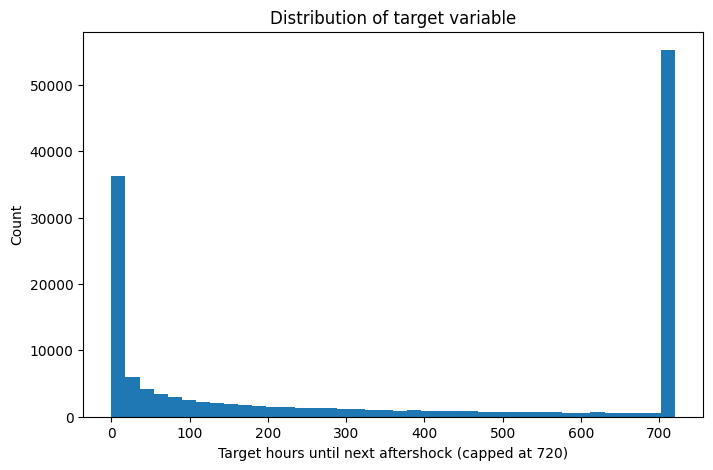

In [42]:
plt.figure(figsize=(8, 5))
plt.hist(target_df["target_hours_capped"], bins=40)
plt.xlabel("Target hours until next aftershock (capped at 720)")
plt.ylabel("Count")
plt.title("Distribution of target variable")
plt.show()

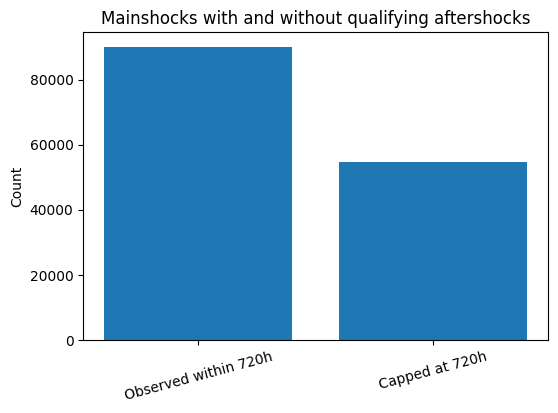

In [43]:
cap_counts = target_df["is_capped_720h"].value_counts().rename_axis("is_capped_720h").reset_index(name="count")
cap_counts["label"] = cap_counts["is_capped_720h"].map({True: "Capped at 720h", False: "Observed within 720h"})

plt.figure(figsize=(6, 4))
plt.bar(cap_counts["label"], cap_counts["count"])
plt.ylabel("Count")
plt.title("Mainshocks with and without qualifying aftershocks")
plt.xticks(rotation=15)
plt.show()

In [44]:
target_df.head(10)

,mainshock_event_id,mainshock_time,mainshock_latitude,mainshock_longitude,mainshock_depth_km,mainshock_magnitude,mainshock_magnitude_type,mainshock_status,mainshock_gap,mainshock_dmin,mainshock_rms,mainshock_nst,next_aftershock_event_id,next_aftershock_time,next_aftershock_magnitude,next_aftershock_distance_km,target_hours_raw,target_hours_capped,has_aftershock_within_720h,is_capped_720h
0,usc000tg4w,2015-01-01 00:10:00.590000+00:00,-3.2525,146.1942,10.00,4.4,mb,reviewed,127.0,1.677,0.52,NaN,usc000thri,2015-01-09 02:08:12.890000+00:00,4.3,47.705351,193.970083,193.970083,True,False
1,usc000tg4x,2015-01-01 00:36:10.240000+00:00,64.6073,-17.6866,5.71,4.3,mb,reviewed,121.0,1.571,0.76,NaN,usc000tg5f,2015-01-01 12:30:12.710000+00:00,4.2,8.910314,11.900686,11.900686,True,False
2,usc000tb39,2015-01-01 00:45:11.940000+00:00,53.7520,-165.6360,61.80,4.2,mb,reviewed,NaN,NaN,1.44,NaN,NaN,NaT,NaN,NaN,NaN,720.000000,False,True
3,usc000tg4y,2015-01-01 00:55:43.100000+00:00,81.6983,118.4063,10.00,4.3,mb,reviewed,75.0,10.371,0.69,NaN,NaN,NaT,NaN,NaN,NaN,720.000000,False,True
4,usc000tg52,2015-01-01 02:58:26.510000+00:00,-18.1824,-177.8246,634.66,4.0,mb,reviewed,146.0,3.948,0.57,NaN,usc000tggd,2015-01-04 20:19:11.740000+00:00,4.4,48.969946,89.345897,89.345897,True,False
5,usc000tb3v,2015-01-01 05:01:10.640000+00:00,38.8957,142.0405,41.39,4.8,mb,reviewed,124.0,1.420,0.80,NaN,NaN,NaT,NaN,NaN,NaN,720.000000,False,True
6,usc000tb42,2015-01-01 06:48:29.670000+00:00,-18.7052,169.1795,223.61,4.6,mb,reviewed,62.0,3.750,0.47,NaN,usb000tiy1,2015-01-18 06:17:21.430000+00:00,4.1,45.840641,407.481044,407.481044,True,False
7,usc000tb46,2015-01-01 06:54:20.570000+00:00,3.4769,-31.7641,10.00,4.7,mb,reviewed,43.0,10.123,0.66,NaN,NaN,NaT,NaN,NaN,NaN,720.000000,False,True
8,usc000tb44,2015-01-01 06:56:58.510000+00:00,36.4411,139.7966,90.64,4.3,mb,reviewed,67.0,0.381,1.00,NaN,NaN,NaT,NaN,NaN,NaN,720.000000,False,True
9,usc000tb4a,2015-01-01 07:12:44.230000+00:00,-11.3818,162.4998,26.24,4.6,mb,reviewed,92.0,3.167,1.22,NaN,NaN,NaT,NaN,NaN,NaN,720.000000,False,True


### Key observations

- The cleaned dataset yields **144,693 candidate mainshocks** with magnitude **$M \ge 4.0$**. This provides a large number of potential training instances for the prediction task, although at this stage these are still **candidate** mainshocks rather than definitively separated independent main events.

- Out of these candidate mainshocks, **90,024 events (62.22%)** have a qualifying earthquake of magnitude **$M \ge 2.5$** within **50 km** and **720 hours**. This suggests that a majority of candidate mainshocks are followed by at least one nearby moderate event within the 30-day window.

- **54,669 events (37.78%)** are **capped at 720 hours**, meaning that no qualifying aftershock was found within the specified time and distance window. This is a substantial proportion of the dataset and indicates that the target variable contains many upper-bound cases.

- The summary statistics of `target_hours_capped` show a **strongly right-skewed distribution**. The median target is about **296.33 hours** (around **12.3 days**), while the 25th percentile is only about **17.83 hours**, showing that many qualifying aftershocks occur relatively soon after the candidate mainshock.

- The **75th percentile is exactly 720 hours**, and the maximum is also **720 hours**, confirming a clear pile-up of observations at the cap value. This means the target is not a standard unconstrained continuous variable, since many cases represent **no observed qualifying aftershock within 30 days** rather than an actual observed wait time of exactly 720 hours.

- The minimum target value is extremely small (**$8.33 \times 10^{-7}$ hours**), indicating that some qualifying events occur almost immediately after the candidate mainshock. These very small gaps should be checked carefully later, as they may reflect closely timed event pairs, catalogue updates, or cases where multiple large events occur in rapid succession.

- Overall, the labelled dataset appears suitable for modelling, but the large mass at **720 hours** suggests that the problem includes a meaningful number of **censored or capped cases**. This should be kept in mind during later modelling and interpretation, since predicting capped cases may be more difficult than predicting ordinary observed aftershock times.

## D. Mainshock-level EDA

This section focuses on the labelled mainshock-level dataset `target_df`, where each row represents one candidate mainshock together with the constructed target variable.

The goal here is to understand:

- the distribution of mainshock properties
- how often aftershocks occur within 720 hours
- whether features such as magnitude, depth, and quality indicators show relationships with the target

### D1. Mainshock magnitude distribution

In [45]:
target_df["mainshock_magnitude"].describe()

count    144693.000000
mean          4.517177
std           0.392873
min           4.000000
25%           4.300000
50%           4.400000
75%           4.700000
max           8.300000
Name: mainshock_magnitude, dtype: float64

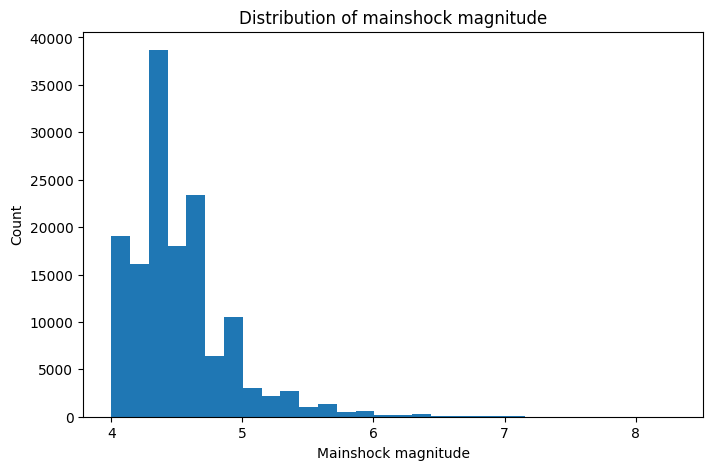

In [46]:
plt.figure(figsize=(8, 5))
plt.hist(target_df["mainshock_magnitude"], bins=30)
plt.xlabel("Mainshock magnitude")
plt.ylabel("Count")
plt.title("Distribution of mainshock magnitude")
plt.show()

### D2. Mainshock depth distribution

In [47]:
target_df["mainshock_depth_km"].describe()

count    144693.000000
mean         88.922827
std         142.131273
min          -1.920000
25%          10.000000
50%          30.205000
75%          99.941000
max         686.390000
Name: mainshock_depth_km, dtype: float64

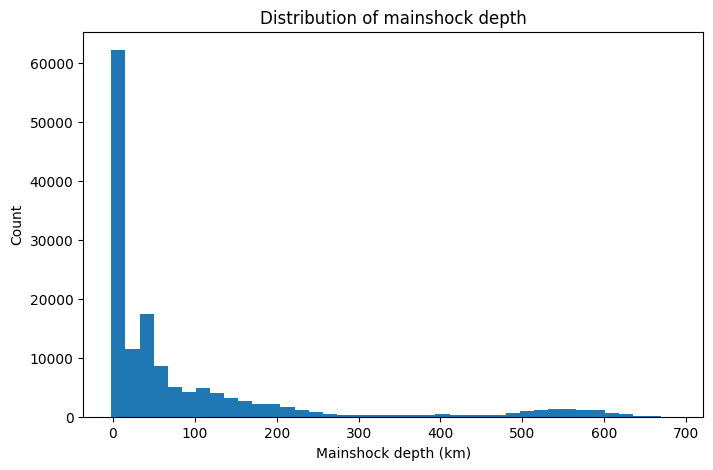

In [48]:
plt.figure(figsize=(8, 5))
plt.hist(target_df["mainshock_depth_km"].dropna(), bins=40)
plt.xlabel("Mainshock depth (km)")
plt.ylabel("Count")
plt.title("Distribution of mainshock depth")
plt.show()

### D3. Mainshock status distribution

In [49]:
mainshock_status_counts = (
    target_df["mainshock_status"]
    .value_counts(dropna=False)
    .rename_axis("mainshock_status")
    .reset_index(name="count")
)

mainshock_status_counts

,mainshock_status,count
0,reviewed,144690
1,automatic,3


### D4. Target distribution for observed aftershocks only

In [50]:
observed_target_df = target_df.loc[target_df["has_aftershock_within_720h"]].copy()

observed_target_df["target_hours_raw"].describe()

count    9.002400e+04
mean     1.433060e+02
std      1.894931e+02
min      8.333333e-07
25%      1.970994e+00
50%      4.761374e+01
75%      2.278612e+02
max      7.199620e+02
Name: target_hours_raw, dtype: float64

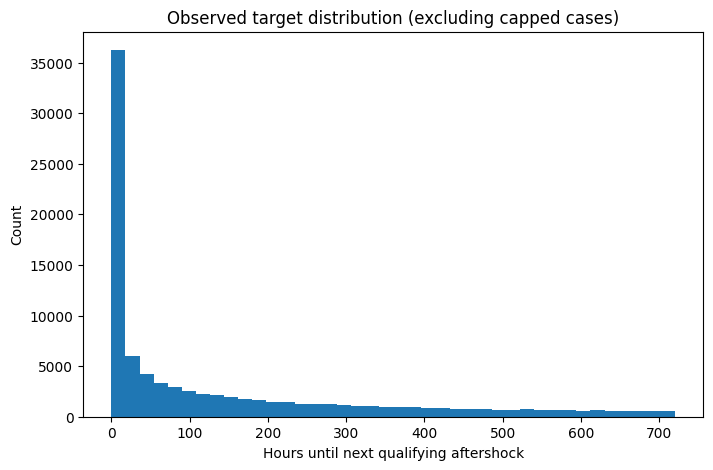

In [51]:
plt.figure(figsize=(8, 5))
plt.hist(observed_target_df["target_hours_raw"].dropna(), bins=40)
plt.xlabel("Hours until next qualifying aftershock")
plt.ylabel("Count")
plt.title("Observed target distribution (excluding capped cases)")
plt.show()

### D5. Mainshock magnitude vs target

In [52]:
mag_bins = pd.cut(
    target_df["mainshock_magnitude"],
    bins=[4, 4.5, 5, 5.5, 6, 7, target_df["mainshock_magnitude"].max()],
    include_lowest=True
)

target_df.groupby(mag_bins)["target_hours_capped"].agg(["count", "mean", "median"])

,count,mean,median
mainshock_magnitude,,,
"(3.999, 4.5]",91940,377.430315,344.957313
"(4.5, 5.0]",40380,352.245712,271.106801
"(5.0, 5.5]",8956,294.104248,97.475883
"(5.5, 6.0]",2404,232.101815,15.381115
"(6.0, 7.0]",909,154.811882,1.241327
"(7.0, 8.3]",104,51.353495,0.291977


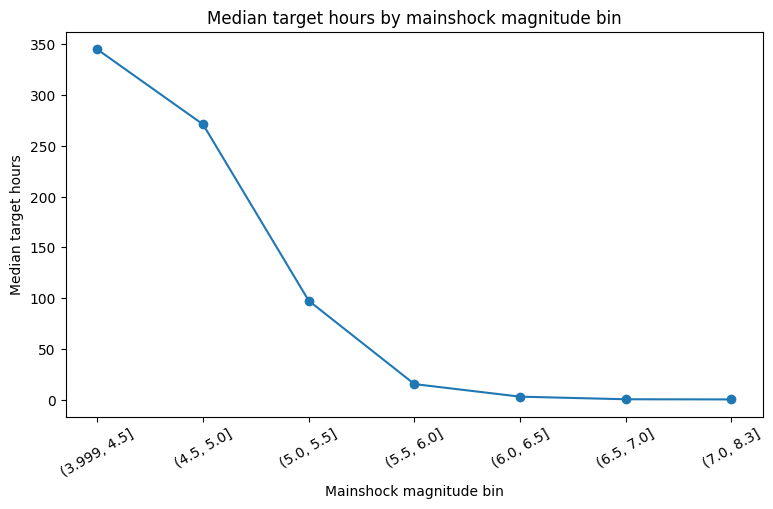

In [53]:
mag_bins = pd.cut(
    target_df["mainshock_magnitude"],
    bins=[4, 4.5, 5, 5.5, 6, 6.5, 7, target_df["mainshock_magnitude"].max()],
    include_lowest=True
)

mag_summary = (
    target_df.groupby(mag_bins)["target_hours_capped"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(mag_summary["mainshock_magnitude"].astype(str), mag_summary["median"], marker="o")
plt.xticks(rotation=30)
plt.xlabel("Mainshock magnitude bin")
plt.ylabel("Median target hours")
plt.title("Median target hours by mainshock magnitude bin")
plt.show()

### D6. Mainshock depth vs target

<Figure size 1000x500 with 0 Axes>

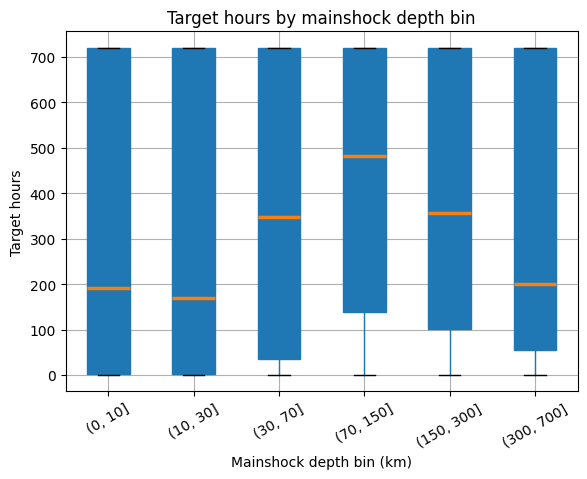

In [54]:
depth_plot_df = target_df.copy()
depth_plot_df["depth_bin"] = pd.cut(
    depth_plot_df["mainshock_depth_km"],
    bins=[0, 10, 30, 70, 150, 300, 700]
)

depth_plot_df = depth_plot_df.dropna(subset=["depth_bin", "target_hours_capped"])

plt.figure(figsize=(10, 5))
depth_plot_df.boxplot(column="target_hours_capped", by="depth_bin", rot=30, patch_artist=True, medianprops={"linewidth": 2.5} )
plt.xlabel("Mainshock depth bin (km)")
plt.ylabel("Target hours")
plt.title("Target hours by mainshock depth bin")
plt.suptitle("")
plt.show()

### D7. Quality-related features vs target

In [55]:
quality_cols = [
    "mainshock_gap",
    "mainshock_dmin",
    "mainshock_rms",
    "mainshock_nst",
]

target_df[quality_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
mainshock_gap,142424.0,106.903895,48.528362,7.0,71.000,102.000,136.000,348.000
mainshock_dmin,142258.0,3.794960,4.872271,0.0,1.174,2.372,4.417,62.626
mainshock_rms,144571.0,0.766433,0.260011,0.0,0.590,0.750,0.930,17.050
mainshock_nst,40194.0,49.826815,41.847402,4.0,23.000,35.000,62.000,619.000


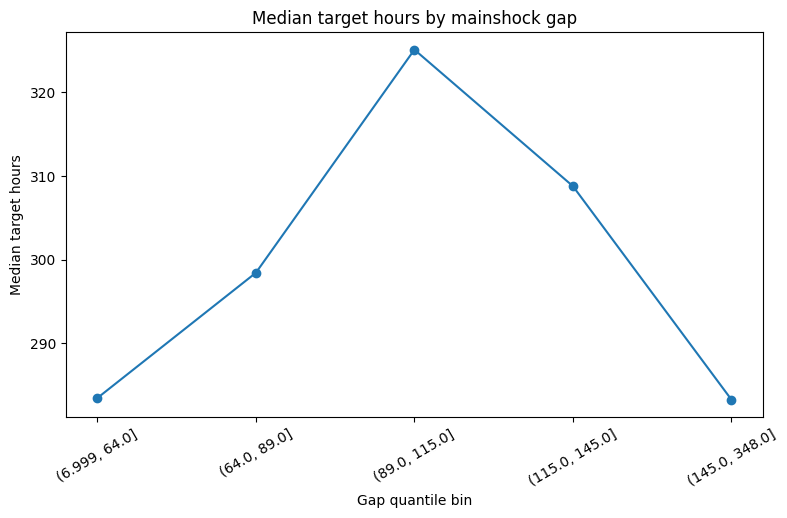

In [56]:
gap_plot_df = target_df.dropna(subset=["mainshock_gap", "target_hours_capped"]).copy()
gap_plot_df["gap_bin"] = pd.qcut(gap_plot_df["mainshock_gap"], q=5, duplicates="drop")

gap_summary = (
    gap_plot_df.groupby("gap_bin")["target_hours_capped"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(gap_summary["gap_bin"].astype(str), gap_summary["median"], marker="o")
plt.xticks(rotation=30)
plt.xlabel("Gap quantile bin")
plt.ylabel("Median target hours")
plt.title("Median target hours by mainshock gap")
plt.show()

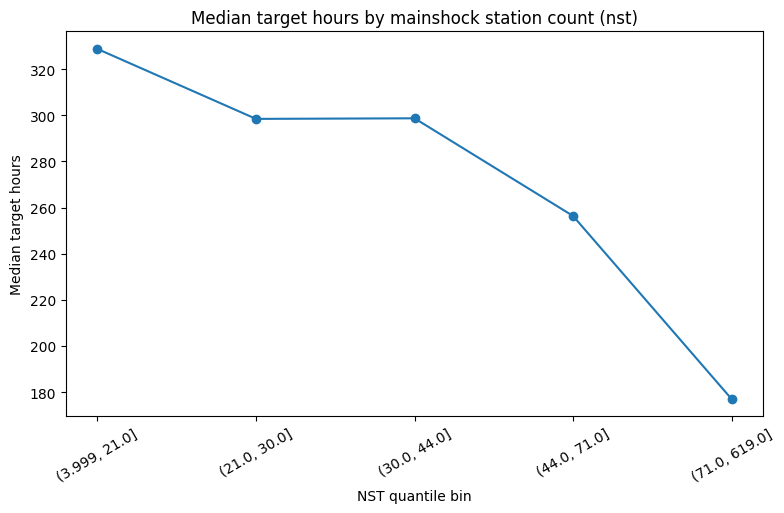

In [57]:
nst_plot_df = target_df.dropna(subset=["mainshock_nst", "target_hours_capped"]).copy()
nst_plot_df["nst_bin"] = pd.qcut(nst_plot_df["mainshock_nst"], q=5, duplicates="drop")

nst_summary = (
    nst_plot_df.groupby("nst_bin")["target_hours_capped"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(nst_summary["nst_bin"].astype(str), nst_summary["median"], marker="o")
plt.xticks(rotation=30)
plt.xlabel("NST quantile bin")
plt.ylabel("Median target hours")
plt.title("Median target hours by mainshock station count (nst)")
plt.show()

### D8. Comparing capped and uncapped mainshocks

In [58]:
target_df.groupby("is_capped_720h")[
    ["mainshock_magnitude", "mainshock_depth_km", "mainshock_gap", "mainshock_dmin", "mainshock_rms", "mainshock_nst"]].mean()

,mainshock_magnitude,mainshock_depth_km,mainshock_gap,mainshock_dmin,mainshock_rms,mainshock_nst
is_capped_720h,,,,,,
False,4.535104,96.964106,107.404031,3.436360,0.761782,50.841642
True,4.487658,75.681170,106.084419,4.381602,0.774099,48.100013


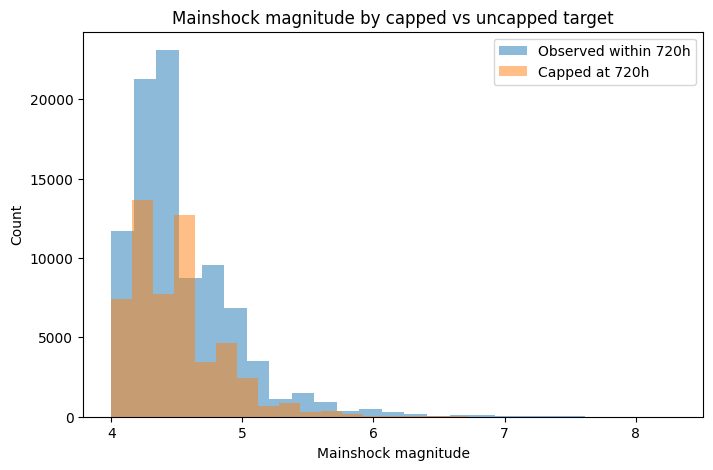

In [59]:
plt.figure(figsize=(8, 5))

for capped_value, label in [(False, "Observed within 720h"), (True, "Capped at 720h")]:
    subset = target_df.loc[target_df["is_capped_720h"] == capped_value, "mainshock_magnitude"]
    plt.hist(subset, bins=25, alpha=0.5, label=label)

plt.xlabel("Mainshock magnitude")
plt.ylabel("Count")
plt.title("Mainshock magnitude by capped vs uncapped target")
plt.legend()
plt.show()

### D9. Correlation table

In [60]:
numeric_cols = [
    "mainshock_magnitude",
    "mainshock_depth_km",
    "mainshock_gap",
    "mainshock_dmin",
    "mainshock_rms",
    "mainshock_nst",
    "target_hours_capped",
]

target_df[numeric_cols].corr(numeric_only=True)

,mainshock_magnitude,mainshock_depth_km,mainshock_gap,mainshock_dmin,mainshock_rms,mainshock_nst,target_hours_capped
mainshock_magnitude,1.000000,-0.153723,-0.418919,0.102114,0.100966,0.627501,-0.100333
mainshock_depth_km,-0.153723,1.000000,-0.062244,-0.022975,-0.055263,0.008124,-0.018332
mainshock_gap,-0.418919,-0.062244,1.000000,0.018844,-0.090443,-0.429089,-0.006039
mainshock_dmin,0.102114,-0.022975,0.018844,1.000000,-0.085901,-0.069097,0.069312
mainshock_rms,0.100966,-0.055263,-0.090443,-0.085901,1.000000,0.022317,0.025115
mainshock_nst,0.627501,0.008124,-0.429089,-0.069097,0.022317,1.000000,-0.056591
target_hours_capped,-0.100333,-0.018332,-0.006039,0.069312,0.025115,-0.056591,1.000000


### Key observations

- The labelled dataset contains **144,693 candidate mainshocks**, with magnitudes ranging from **4.0 to 8.3**. The distribution is concentrated near the lower end of the threshold, with a **median magnitude of 4.4** and **75% of events at or below 4.7**, showing that most candidate mainshocks are moderate rather than very large earthquakes.

- Mainshock depth is **strongly right-skewed**. While the mean depth is about **88.9 km**, the median is only **30.2 km**, indicating that most events are relatively shallow but a smaller number of very deep earthquakes pull the average upward. The presence of a minimum depth of **-1.92 km** suggests that a small number of physically questionable or metadata-related values may still need to be checked.

- Nearly all mainshock records are marked as **reviewed**, with **144,690** labelled `"reviewed"` and only **3** labelled `"automatic"`. This indicates that the labelled dataset is dominated by reviewed seismic records, so most mainshock entries are based on human-checked event solutions rather than purely automatic detections.

- Among the **90,024** mainshocks with a qualifying aftershock within 720 hours, the waiting time is highly skewed toward shorter durations. The median observed waiting time is only about **47.6 hours**, while the lower quartile is about **2.0 hours**, indicating that many qualifying aftershocks occur quite soon after the mainshock. At the same time, the mean is much higher at **143.3 hours**, showing that a smaller number of long waits create a long right tail.

- Mainshock magnitude shows the clearest relationship with the target among the variables examined. As magnitude increases, the median capped target generally decreases sharply:
  - **4.0–4.5:** median about **345.0 hours**
  - **4.5–5.0:** median about **271.1 hours**
  - **5.0–5.5:** median about **97.5 hours**
  - **5.5–6.0:** median about **15.4 hours**
  - **6.0–7.0:** median about **1.24 hours**
  - **7.0–8.3:** median about **0.29 hours**  
  This suggests that larger mainshocks tend to be followed by qualifying aftershocks much more quickly than smaller mainshocks.

- The quality-related variables show mixed usefulness. `mainshock_gap`, `mainshock_dmin`, and `mainshock_rms` have broad ranges, while `mainshock_nst` is available for only **40,194** out of **144,693** rows, meaning station count is substantially missing and may require special handling if used as a model feature.

- Comparing capped and uncapped cases shows meaningful differences. Mainshocks with a qualifying aftershock within 720 hours tend to have:
  - slightly **larger magnitudes** (**4.535** vs **4.488**),
  - **greater average depth** (**97.0 km** vs **75.7 km**),
  - **smaller average `dmin`** (**3.44** vs **4.38**),
  - and slightly **higher average `nst`** (**50.8** vs **48.1**).  
  This suggests that stronger and somewhat better-constrained events may be more likely to produce an observed qualifying aftershock within the prediction window.

- The correlation matrix suggests that most simple linear relationships with the target are weak, but **mainshock magnitude** has the strongest signal among the variables examined, with a correlation of about **-0.10** with `target_hours_capped`. This negative relationship is consistent with the binning results: larger mainshocks are generally associated with shorter waiting times to the next qualifying aftershock.

- Overall, these results suggest that **mainshock magnitude** is likely to be one of the most informative predictors, while **depth** and quality-related variables may provide additional but weaker signal. At the same time, the target remains highly skewed and affected by the **720-hour cap**, which means future modelling steps should account for censoring and non-normality rather than relying only on simple linear assumptions.

## E. Initial feature ideas

This section explores a few simple engineered features that may help predict the time until the next qualifying aftershock.

The main idea is to capture the recent seismic context around each mainshock, such as:

- how many nearby earthquakes happened recently
- how large the recent nearby earthquakes were
- how long it had been since the last nearby earthquake
- whether mainshocks in different regions behave differently

These are still exploratory features and will help us understand what kinds of information may be useful for modelling.

In [61]:
FEATURE_PATH = Path("data/processed/comcat/mainshock_model_dataset.parquet")
FORCE_RECOMPUTE = False


USE_CACHED_FEATURES = FEATURE_PATH.exists() and not FORCE_RECOMPUTE

if USE_CACHED_FEATURES:
    feature_df = pd.read_parquet(FEATURE_PATH)
    print(f"Loaded cached feature dataset from: {FEATURE_PATH}")
    print(feature_df.shape)
else:
    print("Cached feature dataset not found. Run the feature engineering cells below.")

Loaded cached feature dataset from: data/processed/comcat/mainshock_model_dataset.parquet
(144693, 26)


In [62]:
if not USE_CACHED_FEATURES:
    feature_df = target_df.copy()

# use the cleaned event table as the historical event source
events_df = comcat_df_clean.sort_values("time").reset_index(drop=True)

feature_df[[
    "mainshock_event_id",
    "mainshock_time",
    "mainshock_latitude",
    "mainshock_longitude",
    "mainshock_magnitude",
    "target_hours_capped",
]].head()

,mainshock_event_id,mainshock_time,mainshock_latitude,mainshock_longitude,mainshock_magnitude,target_hours_capped
0,usc000tg4w,2015-01-01 00:10:00.590000+00:00,-3.2525,146.1942,4.4,193.970083
1,usc000tg4x,2015-01-01 00:36:10.240000+00:00,64.6073,-17.6866,4.3,11.900686
2,usc000tb39,2015-01-01 00:45:11.940000+00:00,53.7520,-165.6360,4.2,720.000000
3,usc000tg4y,2015-01-01 00:55:43.100000+00:00,81.6983,118.4063,4.3,720.000000
4,usc000tg52,2015-01-01 02:58:26.510000+00:00,-18.1824,-177.8246,4.0,89.345897


### E1. Prior local seismicity counts

A mainshock that occurs in an already active area may behave differently from one that occurs in a relatively quiet area.

To explore this, we count how many earthquakes occurred within 50 km of the mainshock location in the previous:

- 7 days
- 30 days

We also count how many of those prior nearby events had magnitude $M \ge 2.5$.

In [63]:
if not USE_CACHED_FEATURES:
    PRIOR_RADIUS_KM = 50.0

    prior_7d_counts = []
    prior_30d_counts = []
    prior_7d_m25_counts = []
    prior_30d_m25_counts = []

    for _, row in feature_df.iterrows():
        main_time = row["mainshock_time"]
        main_lat = row["mainshock_latitude"]
        main_lon = row["mainshock_longitude"]

        prior_events = events_df.loc[events_df["time"] < main_time].copy()

        if prior_events.empty:
            prior_7d_counts.append(0)
            prior_30d_counts.append(0)
            prior_7d_m25_counts.append(0)
            prior_30d_m25_counts.append(0)
            continue

        prior_events["distance_km"] = haversine_km(
            main_lat,
            main_lon,
            prior_events["latitude"].values,
            prior_events["longitude"].values,
        )

        nearby_prior = prior_events.loc[prior_events["distance_km"] <= PRIOR_RADIUS_KM].copy()

        prior_7d = nearby_prior.loc[nearby_prior["time"] >= main_time - pd.Timedelta(days=7)]
        prior_30d = nearby_prior.loc[nearby_prior["time"] >= main_time - pd.Timedelta(days=30)]

        prior_7d_counts.append(len(prior_7d))
        prior_30d_counts.append(len(prior_30d))
        prior_7d_m25_counts.append((prior_7d["magnitude"] >= 2.5).sum())
        prior_30d_m25_counts.append((prior_30d["magnitude"] >= 2.5).sum())

    feature_df["prior_7d_event_count_50km"] = prior_7d_counts
    feature_df["prior_30d_event_count_50km"] = prior_30d_counts
    feature_df["prior_7d_m25_count_50km"] = prior_7d_m25_counts
    feature_df["prior_30d_m25_count_50km"] = prior_30d_m25_counts

feature_df[[
    "prior_7d_event_count_50km",
    "prior_30d_event_count_50km",
    "prior_7d_m25_count_50km",
    "prior_30d_m25_count_50km",
]].describe().T

,count,mean,std,min,25%,50%,75%,max
prior_7d_event_count_50km,144693.0,7.445861,38.274107,0.0,0.0,0.0,2.0,1883.0
prior_30d_event_count_50km,144693.0,12.276731,67.674940,0.0,0.0,1.0,5.0,6131.0
prior_7d_m25_count_50km,144693.0,7.445861,38.274107,0.0,0.0,0.0,2.0,1883.0
prior_30d_m25_count_50km,144693.0,12.276731,67.674940,0.0,0.0,1.0,5.0,6131.0


### E2. Time since the previous nearby earthquake

Another useful idea is to measure how long it had been since the last earthquake occurred near the mainshock location.

This may help distinguish between:

- mainshocks that occurred in an already active sequence
- mainshocks that occurred after a relatively quiet period

In [64]:
if not USE_CACHED_FEATURES:
    time_since_prev_nearby_hours = []

    for _, row in feature_df.iterrows():
        main_time = row["mainshock_time"]
        main_lat = row["mainshock_latitude"]
        main_lon = row["mainshock_longitude"]

        prior_events = events_df.loc[events_df["time"] < main_time].copy()

        if prior_events.empty:
            time_since_prev_nearby_hours.append(np.nan)
            continue

        prior_events["distance_km"] = haversine_km(
            main_lat,
            main_lon,
            prior_events["latitude"].values,
            prior_events["longitude"].values,
        )

        nearby_prior = prior_events.loc[prior_events["distance_km"] <= PRIOR_RADIUS_KM].copy()

        if nearby_prior.empty:
            time_since_prev_nearby_hours.append(np.nan)
        else:
            last_time = nearby_prior["time"].max()
            delta_hours = (main_time - last_time) / pd.Timedelta(hours=1)
            time_since_prev_nearby_hours.append(delta_hours)

    feature_df["time_since_prev_nearby_event_hours"] = time_since_prev_nearby_hours

feature_df["time_since_prev_nearby_event_hours"].describe()

count    1.382160e+05
mean     1.970338e+03
std      5.251502e+03
min      8.333333e-07
25%      1.559330e+01
50%      2.528816e+02
75%      1.440776e+03
max      8.561947e+04
Name: time_since_prev_nearby_event_hours, dtype: float64

### E3. Previous nearby maximum magnitude

The recent strength of nearby seismicity may also matter.

Here we compute the maximum magnitude observed within 50 km of the mainshock location in the previous 30 days.

In [65]:
if not USE_CACHED_FEATURES:
    prior_30d_max_mag = []

    for _, row in feature_df.iterrows():
        main_time = row["mainshock_time"]
        main_lat = row["mainshock_latitude"]
        main_lon = row["mainshock_longitude"]

        prior_events = events_df.loc[
            (events_df["time"] < main_time) &
            (events_df["time"] >= main_time - pd.Timedelta(days=30))
        ].copy()

        if prior_events.empty:
            prior_30d_max_mag.append(np.nan)
            continue

        prior_events["distance_km"] = haversine_km(
            main_lat,
            main_lon,
            prior_events["latitude"].values,
            prior_events["longitude"].values,
        )

        nearby_prior = prior_events.loc[prior_events["distance_km"] <= PRIOR_RADIUS_KM].copy()

        if nearby_prior.empty:
            prior_30d_max_mag.append(np.nan)
        else:
            prior_30d_max_mag.append(nearby_prior["magnitude"].max())

    feature_df["prior_30d_max_magnitude_50km"] = prior_30d_max_mag

feature_df["prior_30d_max_magnitude_50km"].describe()

count    89825.000000
mean         5.135456
std          0.978060
min          2.500000
25%          4.500000
50%          4.800000
75%          5.600000
max          8.300000
Name: prior_30d_max_magnitude_50km, dtype: float64

### E4. Relationship between engineered features and target

Now that we have a few simple candidate features, we can inspect whether they show any visible relationship with the target variable.

These features are chosen to remain interpretable and closely tied to the physical context of each mainshock, without introducing additional clustering assumptions.

In [66]:
engineered_cols = [
    "prior_7d_event_count_50km",
    "prior_30d_event_count_50km",
    "prior_7d_m25_count_50km",
    "prior_30d_m25_count_50km",
    "time_since_prev_nearby_event_hours",
    "prior_30d_max_magnitude_50km",
    "target_hours_capped",
]

feature_df[engineered_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
prior_7d_event_count_50km,144693.0,7.445861,38.274107,0.000000e+00,0.000000,0.000000,2.000000,1883.000000
prior_30d_event_count_50km,144693.0,12.276731,67.674940,0.000000e+00,0.000000,1.000000,5.000000,6131.000000
prior_7d_m25_count_50km,144693.0,7.445861,38.274107,0.000000e+00,0.000000,0.000000,2.000000,1883.000000
prior_30d_m25_count_50km,144693.0,12.276731,67.674940,0.000000e+00,0.000000,1.000000,5.000000,6131.000000
time_since_prev_nearby_event_hours,138216.0,1970.337817,5251.501881,8.333333e-07,15.593303,252.881557,1440.775543,85619.469103
prior_30d_max_magnitude_50km,89825.0,5.135456,0.978060,2.500000e+00,4.500000,4.800000,5.600000,8.300000
target_hours_capped,144693.0,361.196880,317.050634,8.333333e-07,17.833609,296.328481,720.000000,720.000000


In [67]:
feature_df[engineered_cols].corr(numeric_only=True)

,prior_7d_event_count_50km,prior_30d_event_count_50km,prior_7d_m25_count_50km,prior_30d_m25_count_50km,time_since_prev_nearby_event_hours,prior_30d_max_magnitude_50km,target_hours_capped
prior_7d_event_count_50km,1.000000,0.806463,1.000000,0.806463,-0.074539,0.348437,-0.208622
prior_30d_event_count_50km,0.806463,1.000000,0.806463,1.000000,-0.068899,0.278593,-0.184524
prior_7d_m25_count_50km,1.000000,0.806463,1.000000,0.806463,-0.074539,0.348437,-0.208622
prior_30d_m25_count_50km,0.806463,1.000000,0.806463,1.000000,-0.068899,0.278593,-0.184524
time_since_prev_nearby_event_hours,-0.074539,-0.068899,-0.074539,-0.068899,1.000000,-0.409309,0.280645
prior_30d_max_magnitude_50km,0.348437,0.278593,0.348437,0.278593,-0.409309,1.000000,-0.379513
target_hours_capped,-0.208622,-0.184524,-0.208622,-0.184524,0.280645,-0.379513,1.000000


In [68]:
prior_activity_bins = pd.cut(
    feature_df["prior_30d_event_count_50km"],
    bins=[-1, 0, 5, 20, 100, feature_df["prior_30d_event_count_50km"].max()],
    include_lowest=True
)

feature_df.groupby(prior_activity_bins)["target_hours_capped"].agg(["count", "median", "mean"])

,count,median,mean
prior_30d_event_count_50km,,,
"(-1.001, 0.0]",54868,720.000000,557.536039
"(0.0, 5.0]",56202,269.137261,346.771212
"(5.0, 20.0]",18270,22.461716,102.239877
"(20.0, 100.0]",11606,1.414556,24.437990
"(100.0, 6131.0]",3747,0.708433,8.269894


In [69]:
if not USE_CACHED_FEATURES:
    FEATURE_PATH.parent.mkdir(parents=True, exist_ok=True)
    feature_df.to_parquet(FEATURE_PATH, index=False)

### Key observations

- The engineered features are **highly right-skewed**, especially the prior local event counts. For example, the median number of prior events within 50 km in the last 30 days is only **1**, while the maximum reaches **6,131**. This shows that most candidate mainshocks occur in relatively quiet local settings, while a smaller number occur in extremely active seismic regions.

- The **7-day and 30-day local activity features** appear to be informative. As prior local seismicity increases, the time to the next qualifying aftershock becomes much shorter. In particular, mainshocks with **no prior nearby events in the last 30 days** have a median target of **720 hours**, while those with **more than 100 prior nearby events** have a median target of less than **1 hour**. This suggests that recent local seismic activity is strongly associated with faster subsequent aftershocks.

- The features `prior_7d_m25_count_50km` and `prior_30d_m25_count_50km` are currently identical to the general prior event counts. This is because the underlying ComCat dataset was already filtered to **magnitude $M \ge 2.5$**, so counting all prior events is effectively the same as counting prior events with magnitude $M \ge 2.5$. These duplicated features are therefore redundant and can be removed later.

- `time_since_prev_nearby_event_hours` is also strongly skewed. The median is about **253 hours**, but the mean is much larger because some mainshocks occur after very long quiet periods. This suggests that the feature may still be useful, but it will likely need transformation or careful treatment in later modelling.

- `prior_30d_max_magnitude_50km` shows that when there was recent nearby seismicity, the previous local maximum magnitude was typically moderate, with a median of about **4.8**. However, many mainshocks have missing values for this feature, indicating that there was **no nearby event within 50 km in the previous 30 days**.

- The target variable remains **heavily skewed and capped at 720 hours**, which is consistent with the earlier target-construction analysis. This means the prediction problem is not likely to have a simple linear structure, and feature–target relationships are better interpreted through grouped summaries than raw scatter plots.

- Overall, the most useful engineered signals in this section appear to be the measures of **recent local seismic activity**, especially the number of prior nearby events within the past 30 days. These features are physically interpretable and seem closely related to how quickly the next qualifying aftershock occurs.